Title

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('athlete_events.csv')

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [10]:
# Check total missing values
df.isna().sum()

# Percentage of missing values
(df.isna().sum() / len(df)) * 100


ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height    22.193821
Weight    23.191180
Team       0.000000
NOC        0.000000
Games      0.000000
Year       0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal     85.326207
dtype: float64

In [ ]:
num_cols = ['Age', 'Height', 'Weight']  
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [13]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')


In [14]:
df 

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.00000,80.000000,China,CHN,1992 Summer,1992-01-01,Summer,Barcelona,Basketball,Basketball Men's Basketball,Gold
1,2,A Lamusi,M,23.0,170.00000,60.000000,China,CHN,2012 Summer,2012-01-01,Summer,London,Judo,Judo Men's Extra-Lightweight,Gold
2,3,Gunnar Nielsen Aaby,M,24.0,175.33897,70.702393,Denmark,DEN,1920 Summer,1920-01-01,Summer,Antwerpen,Football,Football Men's Football,Gold
3,4,Edgar Lindenau Aabye,M,34.0,175.33897,70.702393,Denmark/Sweden,DEN,1900 Summer,1900-01-01,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.00000,82.000000,Netherlands,NED,1988 Winter,1988-01-01,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.00000,89.000000,Poland-1,POL,1976 Winter,1976-01-01,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,Gold
271112,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014-01-01,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",Gold
271113,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014-01-01,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",Gold
271114,135571,Tomasz Ireneusz ya,M,30.0,185.00000,96.000000,Poland,POL,1998 Winter,1998-01-01,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,Gold


In [12]:
df = df.drop_duplicates().reset_index(drop=True)


In [11]:
# Define bins and labels
bins = [0, 19, 29, 39, 49, 100]  # 100 as an upper limit placeholder
labels = ['0-19', '20–29', '30–39', '40–49', '50+']

# Create new Age_Group column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Show result
df[['Age', 'Age_Group']].head()


,Age,Age_Group
0,24.0,20–29
1,23.0,20–29
2,24.0,20–29
3,34.0,30–39
4,21.0,20–29


In [19]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Age_Group
0,1,A Dijiang,M,24.0,180.00000,80.000000,China,CHN,1992 Summer,1992-01-01,Summer,Barcelona,Basketball,Basketball Men's Basketball,Gold,20–29
1,2,A Lamusi,M,23.0,170.00000,60.000000,China,CHN,2012 Summer,2012-01-01,Summer,London,Judo,Judo Men's Extra-Lightweight,Gold,20–29
2,3,Gunnar Nielsen Aaby,M,24.0,175.33897,70.702393,Denmark,DEN,1920 Summer,1920-01-01,Summer,Antwerpen,Football,Football Men's Football,Gold,20–29
3,4,Edgar Lindenau Aabye,M,34.0,175.33897,70.702393,Denmark/Sweden,DEN,1900 Summer,1900-01-01,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,30–39
4,5,Christine Jacoba Aaftink,F,21.0,185.00000,82.000000,Netherlands,NED,1988 Winter,1988-01-01,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,Gold,20–29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269710,135569,Andrzej ya,M,29.0,179.00000,89.000000,Poland-1,POL,1976 Winter,1976-01-01,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,Gold,20–29
269711,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014-01-01,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",Gold,20–29
269712,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014-01-01,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",Gold,20–29
269713,135571,Tomasz Ireneusz ya,M,30.0,185.00000,96.000000,Poland,POL,1998 Winter,1998-01-01,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,Gold,30–39


In [27]:
Avg_Height = df ["Height"].mean()
print(Avg_Height)

175.33895323752947


In [23]:
df['Century'] = (df['Year'].year // 100) + 1
df[['Year', 'Century']].head(10)


AttributeError: 'Series' object has no attribute 'year'

In [28]:
avg_age_event = df.groupby('Event')['Age'].mean().reset_index()
avg_age_event.head()


,Event,Age
0,Aeronautics Mixed Aeronautics,26.000000
1,Alpine Skiing Men's Combined,24.100352
2,Alpine Skiing Men's Downhill,24.083770
3,Alpine Skiing Men's Giant Slalom,23.330452
4,Alpine Skiing Men's Slalom,23.523323


In [23]:
# Filter gold medal entries
gold_medals = df[df['Medal'] == 'Gold']

# Count gold medals per country
top_10_gold = gold_medals['NOC'].value_counts().head(10)
top_10_gold


NOC
USA    15605
FRA    11277
GBR    10721
ITA     9605
CAN     8791
GER     8314
JPN     7758
SWE     7234
AUS     6665
HUN     5849
Name: count, dtype: int64

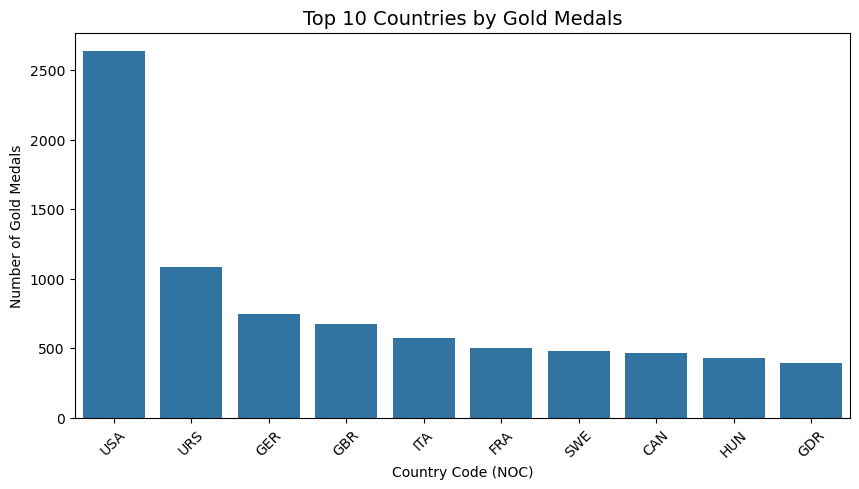

In [29]:
gold_df = df[df["Medal"] == "Gold"]
top10_gold = gold_df["NOC"].value_counts().head(10)
top10_gold
plt.figure(figsize=(10,5))
sns.barplot(x=top10_gold.index, y=top10_gold.values)
plt.title("Top 10 Countries by Gold Medals", fontsize=14)
plt.xlabel("Country Code (NOC)")
plt.ylabel("Number of Gold Medals")
plt.xticks(rotation=45)
plt.show()

In [30]:
# Drop rows with no medal
medals_df = df[df['Medal'] != 'None']

# Count medals per athlete within each sport
athlete_medals = medals_df.groupby(['Sport', 'Name']).size().reset_index(name='Total_Medals')

top_athletes_per_sport = (
    athlete_medals.sort_values(by=['Sport', 'Total_Medals'], ascending=[True, False])
    .drop_duplicates(subset='Sport')
)

top_athletes_per_sport.head()


,Sport,Name,Total_Medals
0,Aeronautics,Hermann Schreiber,1
1463,Alpine Skiing,Kjetil Andr Aamodt,20
2735,Alpinism,Antarge Sherpa,1
3067,Archery,Gerard Theodor Hubert Van Innis,11
4769,Art Competitions,Jean Lucien Nicolas Jacoby,9


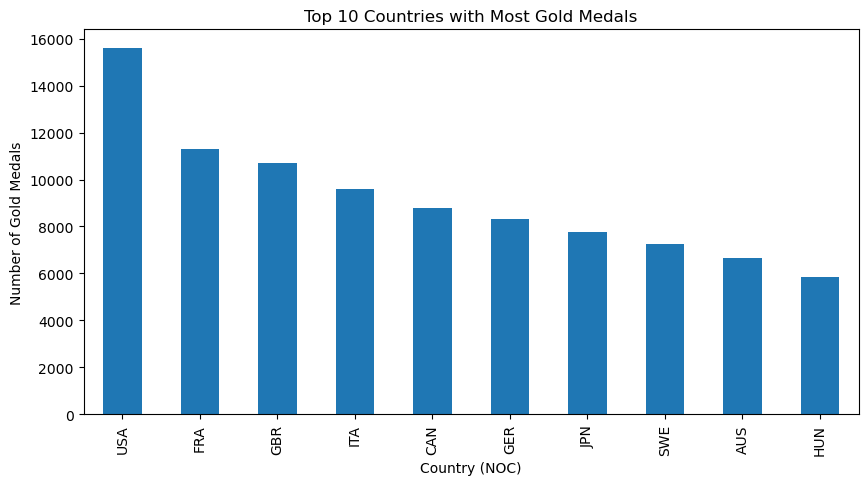

In [27]:
# Filter only gold medal entries
gold_medals = df[df['Medal'] == 'Gold']

# Count by country
top_10_gold = gold_medals['NOC'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))
top_10_gold.plot(kind='bar')
plt.title('Top 10 Countries with Most Gold Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Gold Medals')
plt.show()


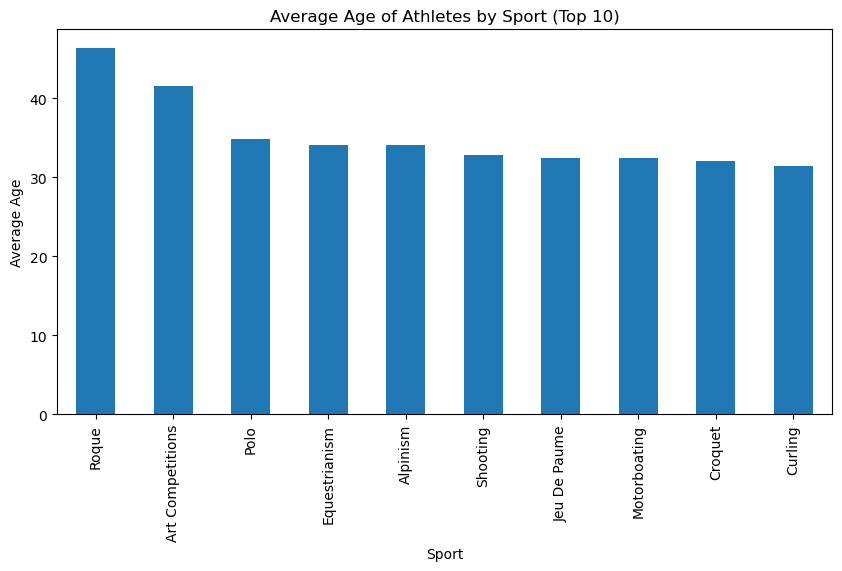

In [28]:
# Average age per sport
avg_age_sport = df.groupby('Sport')['Age'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
avg_age_sport.plot(kind='bar')
plt.title('Average Age of Athletes by Sport (Top 10)')
plt.xlabel('Sport')
plt.ylabel('Average Age')
plt.show()


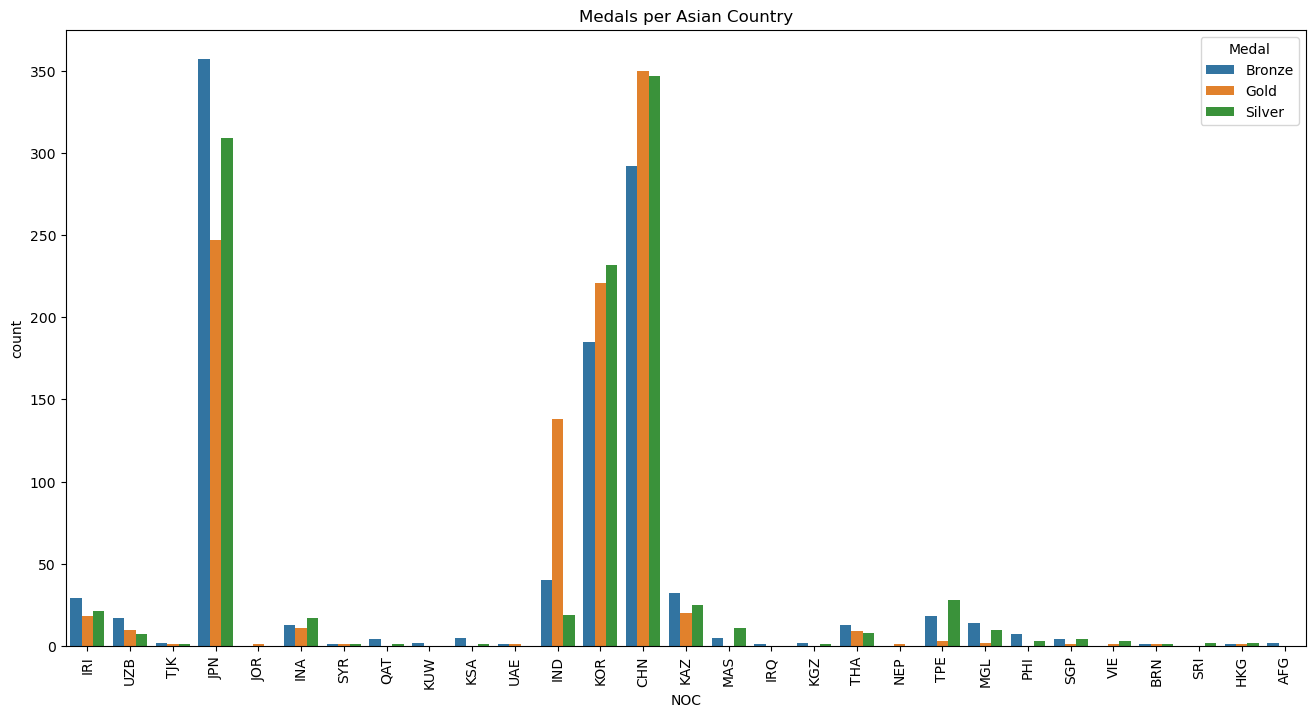

In [31]:
asian_nocs = [
    "CHN","IND","JPN","KOR","KAZ","IRI","TPE","THA","MAS","INA","PHI","SGP","HKG",
    "QAT","UAE","KSA","KUW","BRN","JOR","IRQ","SYR","LBN","PLE","VIE","MGL",
    "KGZ","TJK","UZB","AFG","BAN","MDV","NEP","SRI","TLS"
]
df_asia = df[df["NOC"].isin(asian_nocs)]
df_medals_asia = df_asia[df_asia["Medal"].notna()]
plt.figure(figsize=(16, 8))
sns.countplot(x="NOC", hue="Medal", data=df_medals_asia)
plt.title("Medals per Asian Country")
plt.xticks(rotation=90)
plt.show()

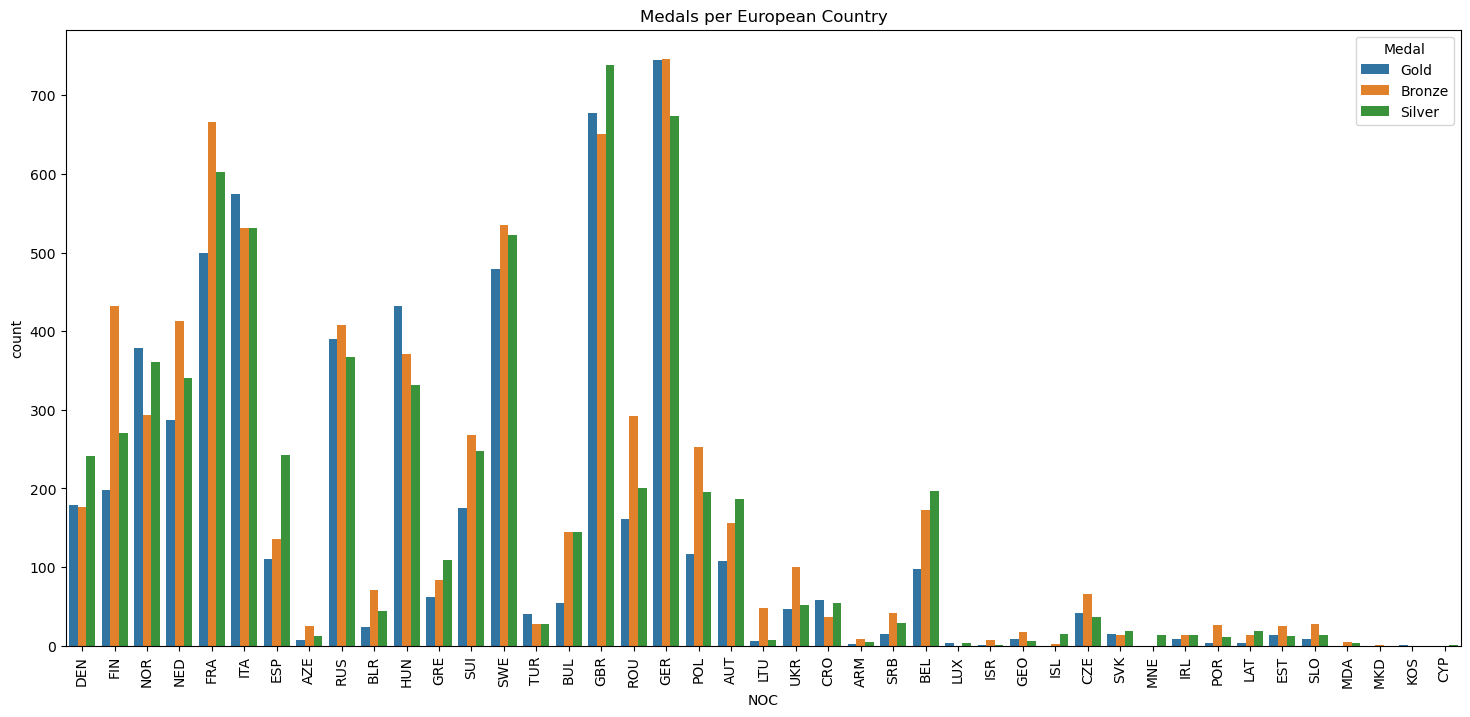

In [32]:
europe_nocs = [
    "ALB","AND","ARM","AUT","AZE","BEL","BLR","BIH","BUL","CRO","CYP","CZE","DEN","EST",
    "FIN","FRA","GEO","GER","GBR","GRE","HUN","ISL","IRL","ISR","ITA","KOS","LAT","LTU",
    "LUX","MKD","MLT","MDA","MNE","NED","NOR","POL","POR","ROU","RUS","SMR","SRB","SVK",
    "SLO","ESP","SWE","SUI","TUR","UKR"
]
df_europe = df[df["NOC"].isin(europe_nocs)]
df_medals_europe = df_europe[df_europe["Medal"].notna()]
plt.figure(figsize=(18, 8))
sns.countplot(x="NOC", hue="Medal", data=df_medals_europe)
plt.title("Medals per European Country")
plt.xticks(rotation=90)
plt.show()